- All helper utilities live in `visualize_run.py` (paths/globs, metrics I/O, and plotting).
- A run directory is expected to contain `artifacts/final_fixed_eval_outputs.pt` and `metrics.json`.

In [1]:
from visualize_run import get_metrics
from visualize_results import plot_rows_scatter
import pandas as pd

In [9]:
# Provide explicit run directories (absolute or relative to the directory containing visualize_run.py).
RUN_DIRS = [
    # Example:
    # '../outputs/runs/baseline/poi_d3_c1',
    # '../outputs/runs/baseline/poi_d3_c2',
]

# Or/and provide glob patterns that match run directories (relative unless absolute).
RUN_GLOBS = [
    # Examples:
    # '../outputs/runs/baseline/euc_*',
    # '../outputs/runs/curv_dim/poincare/general/poi_d512_*',
    '../outputs/runs/curv_dim/poincare/general/poi_d*',
    # '../outputs/runs/baseline/sph_*',
]

# leave empty to print all metrics
DEFAULT_METRICS = [
    # "val/loss_best",
    # "val/loss",
    # "test/loss",
    # "test_sample/mmd",
    # "test_sample/sinkhorn_knopp",
    # "test_vec/rfm_loss",
    # "test_vec/alignment",
]

# Where to save generated plot images.
# If relative, it's resolved relative to the directory containing visualize_run.py.
OUT_DIR = 'run_plots'

In [10]:
metrics = get_metrics(RUN_DIRS, RUN_GLOBS, OUT_DIR, default_metrics=DEFAULT_METRICS)
df = pd.DataFrame(metrics)

SKIP (missing files):
  - missing metrics file: /gpfs/home6/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/outputs/runs/curv_dim/poincare/general/poi_d1024_c0p5/metrics.json
SKIP (missing files):
  - missing metrics file: /gpfs/home6/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/outputs/runs/curv_dim/poincare/general/poi_d1024_c1/metrics.json
SKIP (missing files):
  - missing metrics file: /gpfs/home6/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/outputs/runs/curv_dim/poincare/general/poi_d1024_c10/metrics.json
SKIP (missing files):
  - missing metrics file: /gpfs/home6/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/outputs/runs/curv_dim/poincare/general/poi_d1024_c2/metrics.json
SKIP (missing files):
  - missing metrics file: /gpfs/home6/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/outputs/runs/curv_dim/poincare/general/poi_d1024_c3/metrics.json
SKIP (missing files):
  - missing metrics file: /gpfs/home6/scur0108/DL2_proj

Available metrics:
train/loss, train/loss_step, train/loss_epoch, lr-AdamW, nfe, integ_error, val/rfm_loss, val/rfm_loss_epoch, val/loss, val/loss_epoch, val/loss_best, test/loss, test_vec/rfm_loss, test_vec/alignment, test_vec/finite_fraction, test_vec/norm_mean, test_vec/norm_max, test_vec/norm_std, test_vec/norm_p95, test_vec/tangency_violation_abs, test_vec/tangency_violation_rel, test_sample/sinkhorn_knopp, test_sample/tangent_sinkhorn_knopp, test_sample/tangent_to_geodesic_sinkhorn_ratio, test_sample/mmd, test_sample/epsilon_coverage, test_sample/epsilon_precision, test_sample/frechet_variance_pred, test_sample/frechet_variance_target, test_sample/frechet_variance_ratio, test_sample/dispersion_predicted, test_sample/dispersion_target, test_sample/dispersion_ratio, test_sample/volume_scaling_mean_pred, test_sample/volume_scaling_mean_target, test_sample/volume_scaling_variance_pred, test_sample/volume_scaling_variance_target, test_sample/volume_scaling_gap_target_minus_pred, test_

,curvature,val/rfm_loss
general__sph_d1024_c1,1.0,0.000149
general__sph_d512_c1,1.0,0.001043
general__sph_d128_c1,1.0,0.001483
general__sph_d256_c1,1.0,0.009493
general__sph_d64_c1,1.0,0.016968


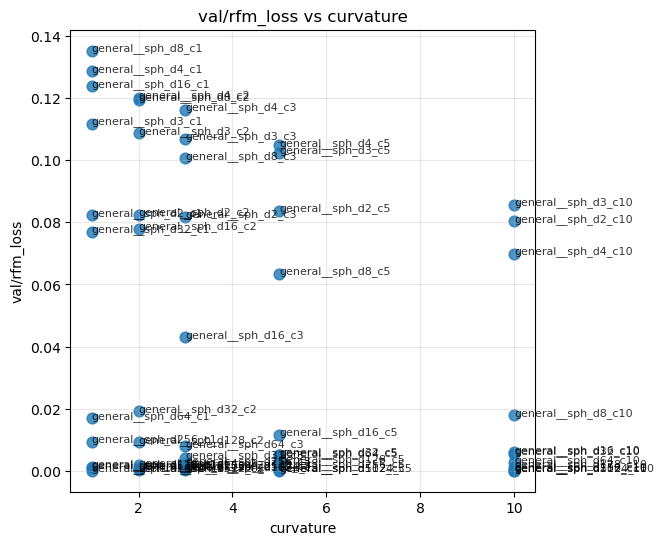

In [4]:
print("Available metrics:")
print(", ".join(map(str, df.index.tolist())))
# df has: rows = metric names, columns = runs (datapoints).
# pick any two rows to compare across runs:
x_metric = 'curvature'
y_metric = 'val/rfm_loss'

fig, ax, plotted = plot_rows_scatter(
    df,
    df.index.get_loc(x_metric),
    df.index.get_loc(y_metric),
    scatter_kwargs={"s": 60, "alpha": 0.8},
    label_points=True,
)

plotted.sort_values([x_metric, y_metric]).head()

Missing runs:
   general__sph_d1024_c1
   general__sph_d1024_c2
   general__sph_d1024_c3
   general__sph_d1024_c5
   general__sph_d1024_c10


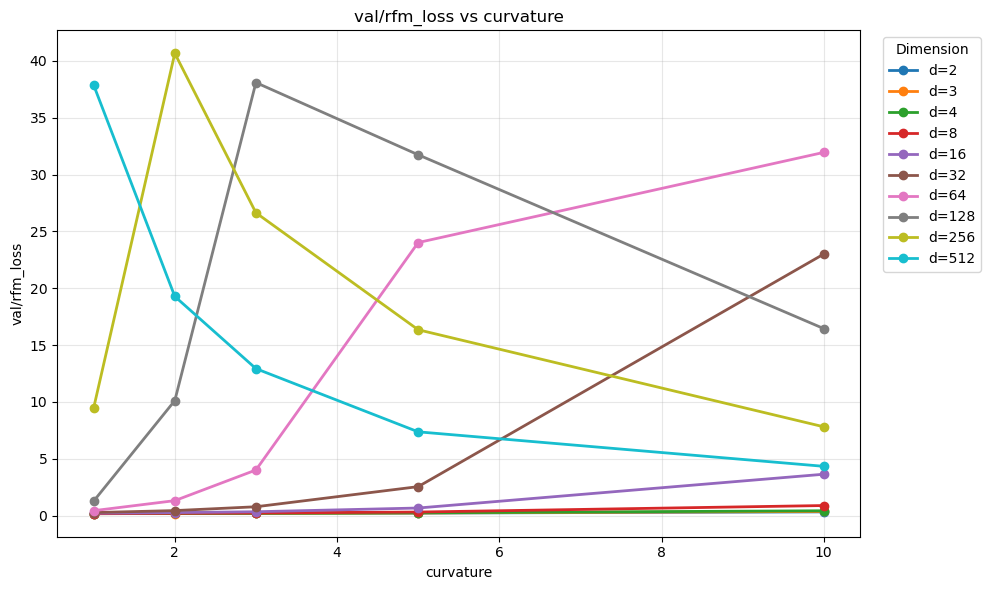

,curvature,val/rfm_loss,dim
general__poi_d2_c1,1.0,0.171250,2
general__poi_d2_c2,2.0,0.184411,2
general__poi_d2_c3,3.0,0.196037,2
general__poi_d2_c5,5.0,0.222327,2
general__poi_d2_c10,10.0,0.326734,2
general__poi_d3_c1,1.0,0.166000,3
general__poi_d3_c2,2.0,0.182885,3
general__poi_d3_c3,3.0,0.197607,3
general__poi_d3_c5,5.0,0.231243,3
general__poi_d3_c10,10.0,0.365455,3


In [14]:

plot_df = df.T.copy()

# ------------------------------------------------------------
# Ensure numeric types
# ------------------------------------------------------------
plot_df["dim"] = pd.to_numeric(plot_df["dim"])
plot_df["curvature"] = pd.to_numeric(plot_df["curvature"])
plot_df["val/rfm_loss"] = pd.to_numeric(plot_df["val/rfm_loss"])

# ------------------------------------------------------------
# Remove curvature = 0.5
# ------------------------------------------------------------
plot_df = plot_df[plot_df["curvature"] != 0.5]

# ------------------------------------------------------------
# Expected configs
# ------------------------------------------------------------
dims = [2, 3, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
curvatures = [1, 2, 3, 5, 10]  # excluding 0.5

# ------------------------------------------------------------
# Check missing runs
# ------------------------------------------------------------
existing = set(
    zip(
        plot_df["dim"],
        plot_df["curvature"],
    )
)

missing = []

for d in dims:
    for c in curvatures:
        if (d, float(c)) not in existing:
            missing.append(f"general__sph_d{d}_c{c}")

if missing:
    print("Missing runs:")
    for m in missing:
        print("  ", m)
else:
    print("All runs present.")

# ------------------------------------------------------------
# Plot lines grouped by dimension
# ------------------------------------------------------------
x_metric = "curvature"
y_metric = "val/rfm_loss"

fig, ax = plt.subplots(figsize=(10, 6))

plotted = []

for dim in sorted(plot_df["dim"].unique()):

    subdf = (
        plot_df[plot_df["dim"] == dim]
        .sort_values(x_metric)
    )

    if len(subdf) == 0:
        continue

    plotted.append(subdf)

    ax.plot(
        subdf[x_metric],
        subdf[y_metric],
        marker="o",
        linewidth=2,
        label=f"d={int(dim)}",
    )

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------
ax.set_xlabel(x_metric)
ax.set_ylabel(y_metric)
ax.set_title(f"{y_metric} vs {x_metric}")
ax.grid(True, alpha=0.3)

ax.legend(
    title="Dimension",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Inspect plotted rows
# ------------------------------------------------------------
plotted = pd.concat(plotted).sort_values(
    ["dim", "curvature"]
)

plotted[
    [x_metric, y_metric, "dim"]
].head(20)